# Hate Speech Classification with Robustness Testing
**Dataset:** HateXplain (Mathew et al., 2021)  
**Model:** BiLSTM for 3-class classification (hate / offensive / normal)  
**Focus:** Robustness to text obfuscation — leet-speak, punctuation insertion, character repetition

---

## Configuration

All parameters are set here. Edit this cell to change the experiment.

In [ ]:
# ── Configuration ────────────────────────────────────────
VOCAB_SIZE    = 20000             # max vocabulary size
EMBEDDING_DIM = 128               # word embedding dimension
HIDDEN_DIM    = 64                # LSTM hidden size
MAX_LEN       = 100               # max sequence length
BATCH_SIZE    = 64                # training batch size
LR            = 1e-3              # learning rate
MAX_EPOCHS    = 10                # upper bound — early stopping will cut short
PATIENCE      = 2                 # early stopping patience
DROPOUT       = 0.5               # dropout rate
AUG_RATE      = 0.5               # fraction of hate/offensive posts to obfuscate
RANDOM_SEED   = 42

# ── Paths ─────────────────────────────────────────────────
DRIVE_DIR    = "/content/drive/MyDrive/hate_speech_project"

# ── Label mapping ─────────────────────────────────────────
LABEL_MAP    = {"hatespeech": 0, "offensive": 1, "normal": 2}
LABEL_NAMES  = {0: "hate", 1: "offensive", 2: "normal"}
COLORS       = {"hate": "#e63946", "offensive": "#f4a261", "normal": "#2a9d8f"}

## Imports & Shared Utilities

In [2]:
import json, re, random, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ All imports done | Device: {device}")

✓ All imports done


In [3]:
# ── Shared: Obfuscation functions ────────────────────────
LEET_MAP = {'a':'4','e':'3','i':'1','o':'0','s':'5','t':'7','g':'9','b':'8'}

def leet_speak(text, rate=0.4):
    """Replace letters with leet equivalents (e.g. hate → h4t3)."""
    return "".join(LEET_MAP[c.lower()] if c.lower() in LEET_MAP
                   and random.random() < rate else c for c in text)

def insert_punctuation(text, rate=0.3):
    """Insert punctuation between chars of random words (e.g. hate → h.a.t.e)."""
    words = text.split()
    for i, w in enumerate(words):
        if len(w) > 3 and random.random() < rate:
            words[i] = random.choice([".","-","_","*"]).join(list(w))
    return " ".join(words)

def char_repeat(text, rate=0.3):
    """Randomly repeat a character in random words (e.g. hate → haate)."""
    words = text.split()
    for i, w in enumerate(words):
        if len(w) > 3 and random.random() < rate:
            idx = random.randint(1, len(w)-2)
            words[i] = w[:idx] + w[idx]*random.randint(2,4) + w[idx+1:]
    return " ".join(words)

def combined_obfuscation(text):
    """Apply all three obfuscation strategies."""
    return char_repeat(insert_punctuation(leet_speak(text, 0.3), 0.2), 0.2)

OBFUSCATION_FNS = {
    "leet_speak":  leet_speak,
    "punctuation": insert_punctuation,
    "char_repeat": char_repeat,
    "combined":    combined_obfuscation,
}

# Preview
random.seed(RANDOM_SEED)
s = "I hate those people they should all leave"
print(f"Original    : {s}")
print(f"Leet        : {leet_speak(s)}")
print(f"Punctuation : {insert_punctuation(s)}")
print(f"Char repeat : {char_repeat(s)}")
print(f"Combined    : {combined_obfuscation(s)}")

Original    : I hate those people they should all leave
Leet        : I h473 thos3 pe0pl3 th3y 5hould all l3ave
Punctuation : I h-a-t-e those people t_h_e_y s*h*o*u*l*d all l_e_a_v_e
Char repeat : I hate those people they should all leave
Combined    : I hate tho53 p-3-0-p-l-3 7*h*3*y shhhould all l34ve


In [ ]:
# ── Shared: PyTorch Dataset ──────────────────────────────
class HateDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=100,
                 augment_fn=None, aug_rate=0.5):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
        self.augment_fn = augment_fn
        self.aug_rate = aug_rate

    def __len__(self): return len(self.texts)

    def _encode(self, text):
        tokens = text.lower().split()
        ids = [self.word2idx.get(w, 1) for w in tokens][:self.max_len]  # 1=UNK
        ids += [0] * (self.max_len - len(ids))  # 0=PAD
        return ids

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        # Apply augmentation to hate (0) and offensive (1) posts
        if self.augment_fn and label in [0, 1] and random.random() < self.aug_rate:
            text = self.augment_fn(text)
        ids = self._encode(text)
        return (torch.tensor(ids, dtype=torch.long),
                torch.tensor(label, dtype=torch.long))


# ── BiLSTM Model ─────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=3, dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        emb = self.embedding(x)
        _, (h, _) = self.lstm(emb)
        h = torch.cat([h[0], h[1]], dim=1)  # concat forward & backward
        return self.fc(self.dropout(h))


# ── Training loop ────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs, lr, patience, criterion=None, label=""):
    optimizer = Adam(model.parameters(), lr=lr)
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_val_loss, best_state, no_improve, stopped_at = float("inf"), None, 0, epochs
    print(f"Training {label} | max {epochs} epochs | patience {patience}\n")
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for step, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            if (step+1) % 50 == 0:
                print(f"  Ep {epoch+1} | Step {step+1}/{len(train_loader)} | Loss {loss.item():.4f}")
        avg_train = total_loss / len(train_loader)
        # Validation (always unweighted)
        model.eval()
        val_loss, all_preds, all_labels = 0.0, [], []
        val_criterion = nn.CrossEntropyLoss()
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                val_loss += val_criterion(out, y).item()
                all_preds.extend(out.argmax(dim=-1).cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        avg_val = val_loss / len(val_loader)
        val_f1 = f1_score(all_labels, all_preds, average="macro")
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_f1"].append(val_f1)
        print(f"\n── Epoch {epoch+1}/{epochs} ──")
        print(f"   Train loss : {avg_train:.4f}")
        print(f"   Val loss   : {avg_val:.4f}")
        print(f"   Val F1     : {val_f1:.4f}")
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"   ✓ Best model (val_loss={best_val_loss:.4f}, F1={val_f1:.4f})")
        else:
            no_improve += 1
            print(f"   ✗ No improvement ({no_improve}/{patience})")
            if no_improve >= patience:
                stopped_at = epoch + 1
                print(f"\n⚡ Early stopping at epoch {stopped_at}")
                break
        print()
    print(f"Done. Best val_loss={best_val_loss:.4f}")
    return best_state, history, stopped_at


# ── Prediction helper ────────────────────────────────────
def get_predictions(model, texts, labels, word2idx, max_len=100, batch_size=64):
    ds = HateDataset(texts, labels, word2idx, max_len)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    all_preds, all_probs = [], []
    model.eval()
    with torch.no_grad():
        for x, _ in loader:
            out = model(x.to(device))
            probs = torch.softmax(out, dim=-1)
            all_preds.extend(probs.argmax(dim=-1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_probs)


# ── Robustness evaluation ────────────────────────────────
def robustness_eval(model, word2idx, texts, labels, reference_f1=None):
    random.seed(RANDOM_SEED)
    results, obf_cache = {}, {"clean": texts}
    preds_clean, _ = get_predictions(model, texts, labels, word2idx)
    results["clean"] = f1_score(labels, preds_clean, average="macro")
    ref = reference_f1 or results["clean"]
    print(f"  clean          → F1: {results['clean']:.4f}")
    for name, fn in OBFUSCATION_FNS.items():
        obf = [fn(t) for t in texts]
        obf_cache[name] = obf
        p, _ = get_predictions(model, obf, labels, word2idx)
        f1 = f1_score(labels, p, average="macro")
        results[name] = f1
        print(f"  {name:<16} → F1: {f1:.4f}  (drop: {ref-f1:+.4f})")
    return results, obf_cache, preds_clean


# ── Plot helpers ──────────────────────────────────────────
def plot_curves(history, stopped_at=None, title="", save_path="curves.png"):
    n = len(history["train_loss"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(range(1,n+1), history["train_loss"], marker="o", label="Train", color="#457b9d")
    axes[0].plot(range(1,n+1), history["val_loss"],   marker="o", label="Val",   color="#e63946")
    if stopped_at and stopped_at < MAX_EPOCHS:
        axes[0].axvline(stopped_at - PATIENCE, color="gray", linestyle="--", label="Early stop")
    axes[0].set_title(f"Loss per Epoch {title}", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].spines[["top","right"]].set_visible(False)
    axes[1].plot(range(1,n+1), history["val_f1"], marker="o", color="#2a9d8f")
    axes[1].set_title(f"Val Macro F1 {title}", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
    axes[1].spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"✓ Saved {save_path}")


def plot_cm(labels, preds, title="", cmap="Blues", save_path="cm.png"):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["hate","offensive","normal"],
                yticklabels=["hate","offensive","normal"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix {title}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()
    print(f"✓ Saved {save_path}")

print("✓ All shared utilities defined")

---
## Task 1 — Problem Definition & Dataset Understanding

**Task:** Classify social media posts into three categories — *hate speech*, *offensive language*, and *normal*.  
This is an NLP classification problem because it requires understanding context, implicit meaning, and social norms from raw text — not just surface-level keywords.

**Dataset:** [HateXplain](https://github.com/hate-alert/HateXplain) — ~20,000 posts from Twitter and Gab, annotated by 3 workers each. Labels are resolved via majority vote. Posts with no majority (~2–3%) are discarded.

**Known limitations:** class imbalance; annotation subjectivity; English-only; no demographic information on annotators.

In [5]:
BASE_URL = "https://raw.githubusercontent.com/hate-alert/HateXplain/master/Data/"

def download_json(filename):
    with urllib.request.urlopen(BASE_URL + filename) as r:
        return json.loads(r.read().decode())

print("Downloading dataset from GitHub...")
data       = download_json("dataset.json")
split_info = download_json("post_id_divisions.json")
print(f"✓ Total posts: {len(data)} | Splits: {list(split_info.keys())}")

# Inspect one example
sample_id = list(data.keys())[0]
print(f"\n── Sample post ({sample_id}) ──")
print(json.dumps(data[sample_id], indent=2)[:600])

✓ Total posts: 20148 | Splits: ['test', 'train', 'val']

── Sample post (1179055004553900032_twitter) ──
{
  "post_id": "1179055004553900032_twitter",
  "annotators": [
    {
      "label": "normal",
      "annotator_id": 1,
      "target": [
        "None"
      ]
    },
    {
      "label": "normal",
      "annotator_id": 2,
      "target": [
        "None"
      ]
    },
    {
      "label": "normal",
      "annotator_id": 3,
      "target": [
        "None"
      ]
    }
  ],
  "rationales": [],
  "post_tokens": [
    "i",
    "dont",
    "think",
    "im",
    "getting",
    "my",
    "baby",
    "them",
    "white",
    "9",
    "he",
    "has",
    "two",
    "white",
    "j",
    "and",
 


In [6]:
def majority_vote(label_list):
    count = Counter(label_list)
    top   = count.most_common(1)[0]
    return top[0] if top[1] >= 2 else None

def build_dataframe(post_ids):
    rows = []
    for pid in post_ids:
        if pid not in data: continue
        post   = data[pid]
        labels = [a["label"] for a in post["annotators"]]
        vote   = majority_vote(labels)
        if vote is None: continue
        rows.append({"post_id": pid,
                     "text":       " ".join(post["post_tokens"]),
                     "label":      LABEL_MAP[vote],
                     "label_name": LABEL_NAMES[LABEL_MAP[vote]]})
    return pd.DataFrame(rows)

train_df = build_dataframe(split_info["train"])
val_df   = build_dataframe(split_info["val"])
test_df  = build_dataframe(split_info["test"])

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")
print(f"\nLabel distribution (train):\n{train_df['label_name'].value_counts()}")

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv",     index=False)
test_df.to_csv("test.csv",   index=False)
print("\n✓ Saved train.csv / val.csv / test.csv")

Train : 15383 | Val : 1922 | Test : 1924

Label distribution (train):
label_name
normal       6251
hate         4748
offensive    4384
Name: count, dtype: int64

✓ Saved train.csv / val.csv / test.csv


---
## Task 2 — Exploratory Data Analysis

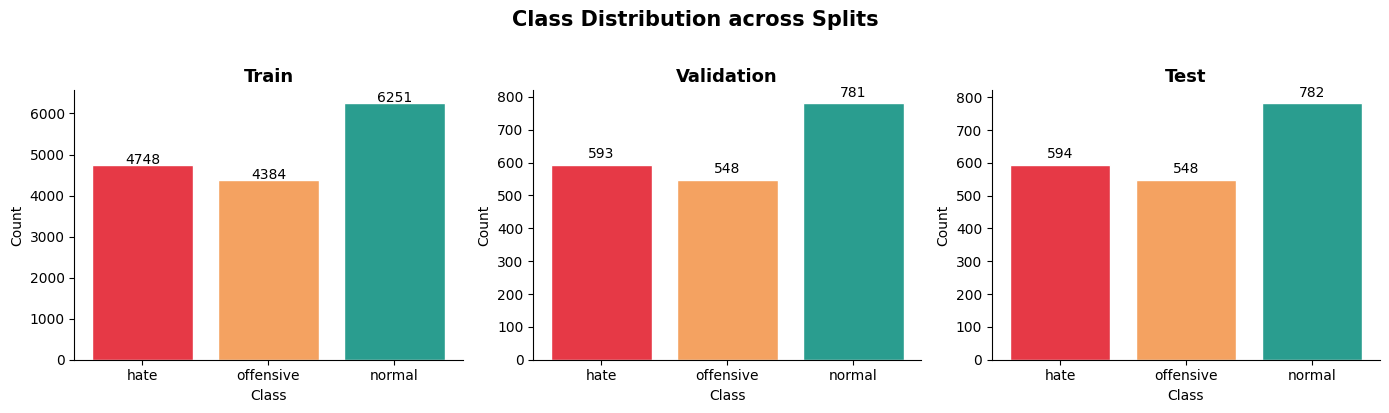

✓ Saved eda_class_distribution.png


In [7]:
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

# ── Class distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [("Train",train_df),("Validation",val_df),("Test",test_df)]):
    counts = df["label_name"].value_counts().reindex(["hate","offensive","normal"])
    bars   = ax.bar(counts.index, counts.values,
                    color=[COLORS[l] for l in counts.index], edgecolor="white")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(v), ha="center", fontsize=10)
    ax.spines[["top","right"]].set_visible(False)
plt.suptitle("Class Distribution across Splits", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Saved eda_class_distribution.png")

── Token count by class ──
             count  mean   std  min   25%   50%   75%    max
label_name                                                  
hate        4748.0  24.5  14.1  2.0  13.0  22.0  36.0  165.0
normal      6251.0  23.4  13.7  2.0  12.0  20.0  34.0   67.0
offensive   4384.0  22.4  13.5  2.0  11.0  20.0  32.0   76.0


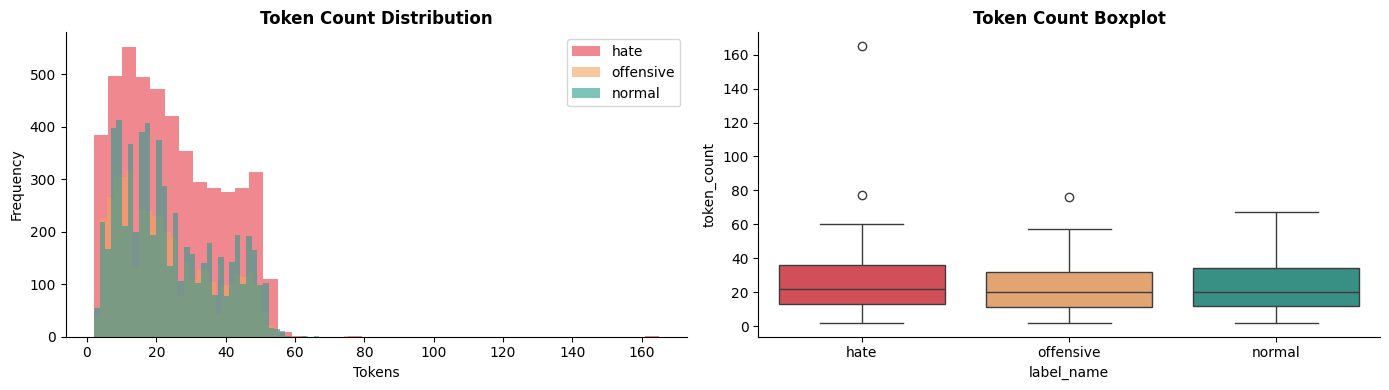

✓ Saved eda_text_length.png


In [8]:
# ── Text length analysis ──────────────────────────────────
train_df["token_count"] = train_df["text"].apply(lambda x: len(str(x).split()))
train_df["char_count"]  = train_df["text"].apply(lambda x: len(str(x)))

print("── Token count by class ──")
print(train_df.groupby("label_name")["token_count"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, color in COLORS.items():
    axes[0].hist(train_df[train_df["label_name"]==label]["token_count"],
                 bins=40, alpha=0.6, label=label, color=color, edgecolor="none")
axes[0].set_title("Token Count Distribution", fontweight="bold")
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Frequency"); axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)

sns.boxplot(data=train_df, x="label_name", y="token_count", palette=COLORS,
            order=["hate","offensive","normal"], ax=axes[1], hue="label_name")
axes[1].set_title("Token Count Boxplot", fontweight="bold")
axes[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("eda_text_length.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Saved eda_text_length.png")

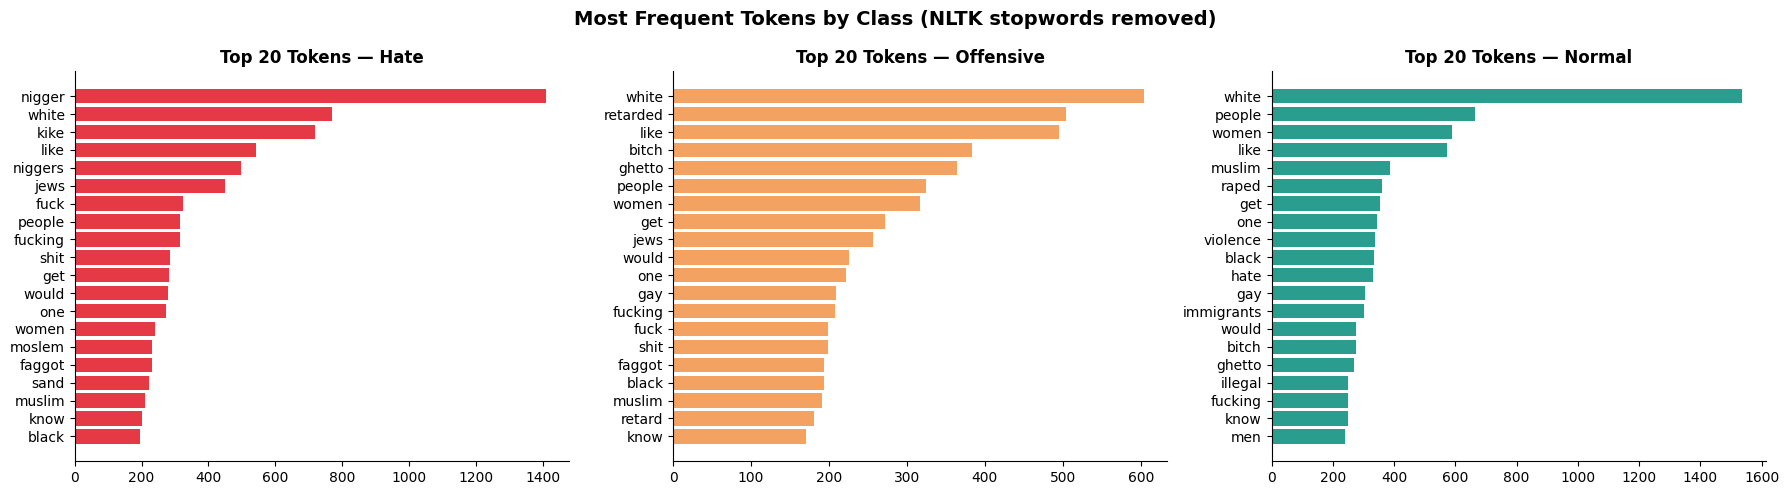

✓ Saved eda_top_tokens.png


In [9]:
# ── Top-20 tokens per class ───────────────────────────────
def get_top_tokens(texts, n=20):
    tokens = []
    for text in texts:
        tokens.extend([w.lower() for w in str(text).split()
                       if w.isalpha() and w.lower() not in STOPWORDS and len(w) > 2])
    return Counter(tokens).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, color) in zip(axes, COLORS.items()):
    top = get_top_tokens(train_df[train_df["label_name"]==label]["text"])
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor="none")
    ax.set_title(f"Top 20 Tokens — {label.capitalize()}", fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)
plt.suptitle("Most Frequent Tokens by Class (NLTK stopwords removed)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_top_tokens.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Saved eda_top_tokens.png")

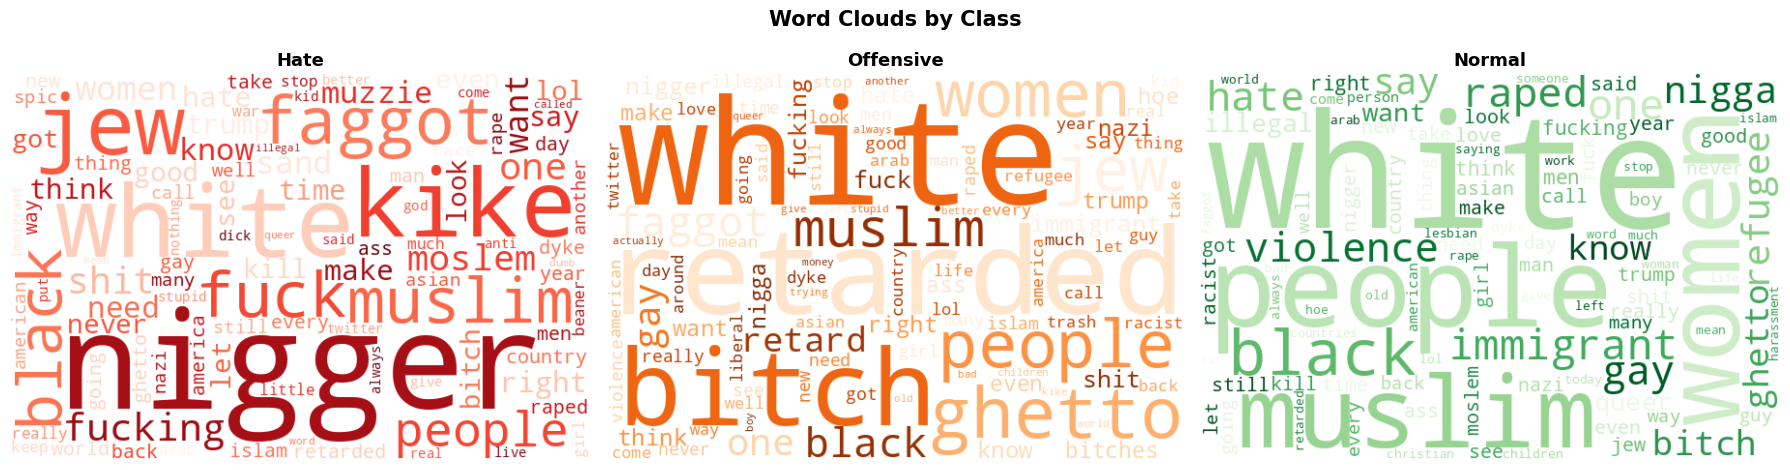

✓ Saved eda_wordclouds.png


In [10]:
# ── Word clouds ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, cmap) in zip(axes, {"hate":"Reds","offensive":"Oranges","normal":"Greens"}.items()):
    text  = " ".join(train_df[train_df["label_name"]==label]["text"].tolist())
    clean = " ".join([w for w in text.split()
                      if w.lower() not in STOPWORDS and w.isalpha() and len(w) > 2])
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=cmap, max_words=100, collocations=False).generate(clean)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    ax.set_title(label.capitalize(), fontsize=13, fontweight="bold")
plt.suptitle("Word Clouds by Class", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_wordclouds.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Saved eda_wordclouds.png")

In [11]:
# ── Summary statistics ────────────────────────────────────
print("══════════════════════════════════════════")
print("        EDA SUMMARY — TRAIN SPLIT")
print("══════════════════════════════════════════")
total = len(train_df)
for label in ["hate","offensive","normal"]:
    n   = (train_df["label_name"]==label).sum()
    avg = train_df[train_df["label_name"]==label]["token_count"].mean()
    print(f"  {label:<12} | n={n:>4} ({n/total*100:.1f}%) | avg tokens={avg:.1f}")
print(f"  {'TOTAL':<12} | n={total}")
print("══════════════════════════════════════════")
print(f"  Overall avg tokens : {train_df['token_count'].mean():.1f}")
print(f"  Overall avg chars  : {train_df['char_count'].mean():.1f}")
print(f"  Max token count    : {train_df['token_count'].max()}")
print(f"  Min token count    : {train_df['token_count'].min()}")

══════════════════════════════════════════
        EDA SUMMARY — TRAIN SPLIT
══════════════════════════════════════════
  hate         | n=4748 (30.9%) | avg tokens=24.5
  offensive    | n=4384 (28.5%) | avg tokens=22.4
  normal       | n=6251 (40.6%) | avg tokens=23.4
  TOTAL        | n=15383
══════════════════════════════════════════
  Overall avg tokens : 23.5
  Overall avg chars  : 126.5
  Max token count    : 165
  Min token count    : 2


---
## Task 3 — Data Preprocessing

Preprocessing is minimal: replace URLs and @mentions with placeholders, strip `#` from hashtags. Text is tokenized at word level and converted to integer indices using a vocabulary built from the training set.

In [12]:
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "[URL]",  text)
    text = re.sub(r"@\w+",            "[USER]", text)
    text = re.sub(r"#(\w+)",           r"\1",   text)
    text = re.sub(r"\s+",              " ",      text).strip()
    return text

for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["text"].apply(clean_text)

print("── Before / After cleaning ──")
for i in range(2):
    print(f"\nOriginal : {train_df['text'].iloc[i]}")
    print(f"Cleaned  : {train_df['clean_text'].iloc[i]}")

── Before / After cleaning ──

Original : u really think i would not have been raped by feral hindu or muslim back in india or bangladesh and a neo nazi would rape me as well just to see me cry
Cleaned  : u really think i would not have been raped by feral hindu or muslim back in india or bangladesh and a neo nazi would rape me as well just to see me cry

Original : the uk has threatened to return radioactive waste to the eu if an agreement cannot be reached can not we keep the radioactive waste and send back all the paki migrants instead
Cleaned  : the uk has threatened to return radioactive waste to the eu if an agreement cannot be reached can not we keep the radioactive waste and send back all the paki migrants instead


In [13]:
# ── Save clean CSVs ───────────────────────────────────────
cols = ["post_id","text","clean_text","label","label_name"]
train_df[cols].to_csv("train_clean.csv", index=False)
val_df[cols].to_csv("val_clean.csv",     index=False)
test_df[cols].to_csv("test_clean.csv",   index=False)
print("✓ Saved train_clean.csv / val_clean.csv / test_clean.csv")

✓ Saved train_clean.csv / val_clean.csv / test_clean.csv


---
## Task 3b — Vocabulary & Sequence Encoding

In [14]:
# ── Build vocabulary from training data ──────────────────
train_df = pd.read_csv("train_clean.csv")
val_df   = pd.read_csv("val_clean.csv")
test_df  = pd.read_csv("test_clean.csv")

MIN_FREQ = 2
word_counts = Counter()
for text in train_df["clean_text"]:
    word_counts.update(str(text).lower().split())

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in word_counts.items():
    if c >= MIN_FREQ:
        word2idx[w] = len(word2idx)

print(f"✓ Vocabulary size: {len(word2idx):,} (min_freq={MIN_FREQ})")
print(f"  Sequence max length: {MAX_LEN}")

# Create DataLoaders
train_ds = HateDataset(train_df["clean_text"].tolist(), train_df["label"].tolist(), word2idx, MAX_LEN)
val_ds   = HateDataset(val_df["clean_text"].tolist(),   val_df["label"].tolist(),   word2idx, MAX_LEN)
test_ds  = HateDataset(test_df["clean_text"].tolist(),  test_df["label"].tolist(),  word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

✓ Vocabulary size: 24,910
  Sequence shape : (15383, 100)


---
## Task 4a — Baseline Training (BiLSTM)

**Model:** Bidirectional LSTM with learned word embeddings (128d). A lightweight deep learning model that captures sequential context without requiring pre-trained transformers.

**Training:** Adam optimizer, lr=1e-3, early stopping on validation loss (patience=2).

In [16]:
# ── Baseline: BiLSTM ────────────────────────────────────
model_4a = BiLSTMClassifier(
    vocab_size=len(word2idx), embed_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM, dropout=DROPOUT
).to(device)

n_params = sum(p.numel() for p in model_4a.parameters() if p.requires_grad)
print(f"✓ Model: BiLSTM | Params: {n_params:,}")

best_state_4a, history_4a, stopped_4a = train_model(
    model_4a, train_loader, val_loader,
    epochs=MAX_EPOCHS, lr=LR, patience=PATIENCE,
    label="— BiLSTM baseline"
)
plot_curves(history_4a, stopped_4a, title="— BiLSTM Baseline",
            save_path="training_curves_4a.png")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,267 (10.17 MB)

 Trainable params: 2,667,267 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 73s 278ms/step - accuracy: 0.5197 - loss: 0.9726 - val_accuracy: 0.6056 - val_loss: 0.8574
Epoch 2/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 79s 265ms/step - accuracy: 0.7023 - loss: 0.7107 - val_accuracy: 0.6176 - val_loss: 0.8749
Epoch 3/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 64s 265ms/step - accuracy: 0.8048 - loss: 0.5082 - val_accuracy: 0.6119 - val_loss: 0.9649
Epoch 4/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 63s 261ms/step - accuracy: 0.8713 - loss: 0.3560 - val_accuracy: 0.6035 - val_loss: 1.1286
Epoch 5/5
241/241 ━━━━━━━━━━━━━━━━━━━━ 64s 264ms/step - accuracy: 0.9113 - loss: 0.2603 - val_accuracy: 0.6108 - val_loss: 1.4705
481/481 ━━━━━━━━━━━━━━━━━━━━ 75s 156ms/step - accuracy: 0.9064 - loss: 0.2634
✓ Baseline trained | Val macro F1: 0.5771


61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step
── Task 4a — Test Set Results ──
              precision    recall  f1-score   support

        hate     0.6411    0.7037    0.6709       594
   offensive     0.4513    0.3887    0.4176       548
      normal     0.6412    0.6560    0.6485       782

    accuracy                         0.5946      1924
   macro avg     0.5779    0.5828    0.5790      1924
weighted avg     0.5871    0.5946    0.5897      1924



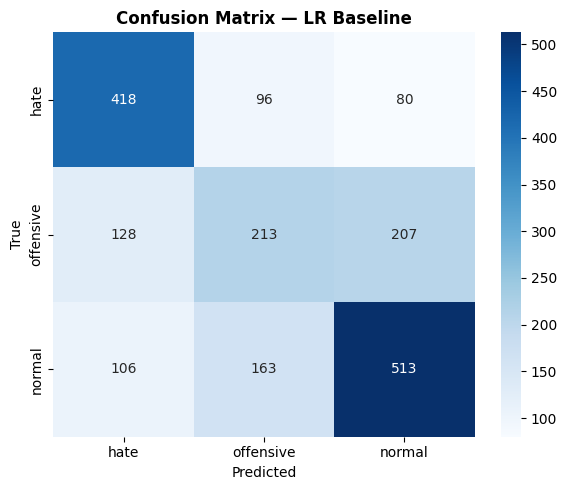

✓ Saved cm_4a.png


In [18]:
# ── Baseline — Test Set Results ──────────────────────────
model_4a.load_state_dict(best_state_4a)
preds_4a, _ = get_predictions(model_4a, test_df["clean_text"].tolist(),
                               test_df["label"].tolist(), word2idx)

print("── Task 4a — Test Set Results ──")
print(classification_report(test_df["label"].values, preds_4a,
                             target_names=["hate","offensive","normal"], digits=4))
plot_cm(test_df["label"].values, preds_4a,
        title="— BiLSTM Baseline", cmap="Blues",
        save_path="cm_4a.png")

---
## Task 4b — Improved Model (Balanced Class Weights)

Same BiLSTM architecture with one improvement:
- **Balanced class weights** — higher weight to minority classes (hate, offensive) during training, to address the class imbalance in HateXplain

In [ ]:
# ── Class weights ─────────────────────────────────────────
labels_array = train_df["label"].values
class_weights = compute_class_weight("balanced", classes=np.array([0,1,2]), y=labels_array)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion_4b = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {LABEL_NAMES[i]:<12} → {w:.4f}")

# Fresh model
model_4b = BiLSTMClassifier(
    vocab_size=len(word2idx), embed_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM, dropout=DROPOUT
).to(device)

best_state_4b, history_4b, stopped_4b = train_model(
    model_4b, train_loader, val_loader,
    epochs=MAX_EPOCHS, lr=LR, patience=PATIENCE,
    criterion=criterion_4b,
    label="— BiLSTM improved"
)
plot_curves(history_4b, stopped_4b, title="— BiLSTM Improved",
            save_path="training_curves_4b.png")

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
── Task 4b — Test Set Results ──
              precision    recall  f1-score   support

        hate     0.6623    0.6835    0.6727       594
   offensive     0.4041    0.5073    0.4498       548
      normal     0.6742    0.5371    0.5979       782

    accuracy                         0.5738      1924
   macro avg     0.5802    0.5760    0.5735      1924
weighted avg     0.5936    0.5738    0.5788      1924



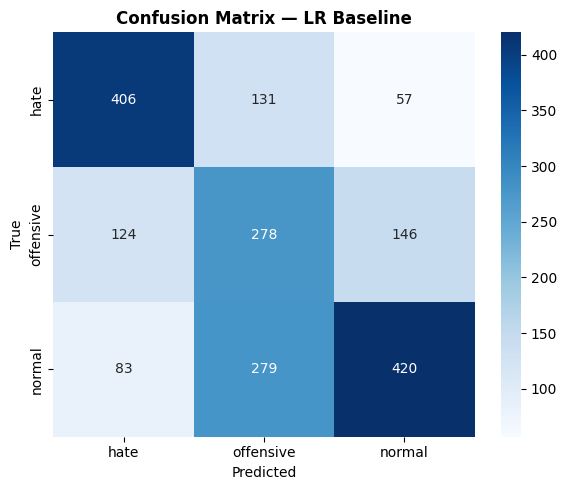

✓ Saved cm_4b.png


In [20]:
# ── Improved — Test Set Results ──────────────────────────
model_4b.load_state_dict(best_state_4b)
preds_4b, _ = get_predictions(model_4b, test_df["clean_text"].tolist(),
                               test_df["label"].tolist(), word2idx)

print("── Task 4b — Test Set Results ──")
print(classification_report(test_df["label"].values, preds_4b,
                             target_names=["hate","offensive","normal"], digits=4))
plot_cm(test_df["label"].values, preds_4b,
        title="— BiLSTM Improved", cmap="Greens",
        save_path="cm_4b.png")

---
## Task 5 — Robustness to Obfuscation

In [23]:
# ── Baseline robustness ──────────────────────────────────
test_texts  = test_df["clean_text"].tolist()
test_labels = test_df["label"].tolist()

print("── Baseline robustness ──")
results_4a, obf_cache, preds_clean_4a = robustness_eval(
    model_4a, word2idx, test_texts, test_labels)

── Baseline robustness ──
  clean          → F1: 0.5790
  leet_speak       → F1: 0.3088  (drop: +0.2702)
  punctuation      → F1: 0.4590  (drop: +0.1201)
  char_repeat      → F1: 0.5309  (drop: +0.0482)
  combined         → F1: 0.3214  (drop: +0.2576)


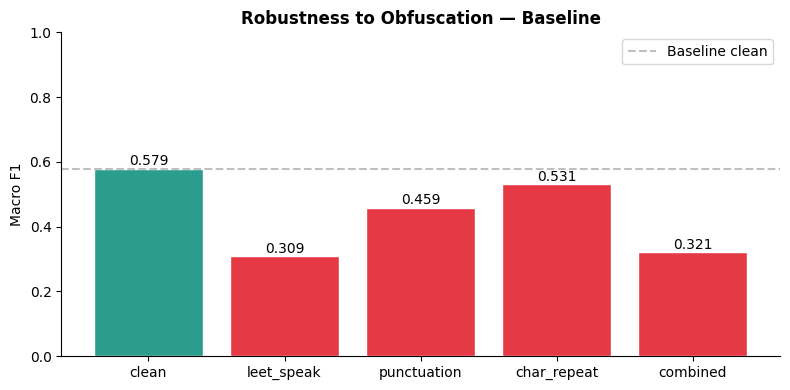

In [25]:
# ── Robustness bar chart — baseline ──────────────────────
fig, ax = plt.subplots(figsize=(8,4))
bar_colors = ["#2a9d8f"] + ["#e63946"]*4
bars = ax.bar(results_4a.keys(), results_4a.values(),
              color=bar_colors, edgecolor="white")
ax.axhline(results_4a["clean"], color="gray", linestyle="--", alpha=0.5, label="Baseline clean")
for bar, v in zip(bars, results_4a.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylabel("Macro F1"); ax.set_ylim(0, 1.0)
ax.set_title("Robustness to Obfuscation — Baseline", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("robustness_baseline.png", dpi=150, bbox_inches="tight"); plt.show()

In [24]:
# ── Per-class breakdown — baseline ───────────────────────
print("── Per-class F1 breakdown — Baseline ──")
header = f"{'Condition':<18} {'hate':>8} {'offensive':>10} {'normal':>8} {'macro':>8}"
print(header); print("─"*len(header))
for name, txt_list in obf_cache.items():
    p, _ = get_predictions(model_4a, txt_list, test_labels, word2idx)
    f1s  = f1_score(test_labels, p, average=None)
    macro = f1_score(test_labels, p, average="macro")
    print(f"  {name:<16} {f1s[0]:8.4f} {f1s[1]:10.4f} {f1s[2]:8.4f} {macro:8.4f}")

── Per-class F1 breakdown — Baseline ──
Condition              hate  offensive   normal    macro
────────────────────────────────────────────────────────
  clean              0.6709     0.4176   0.6485   0.5790
  leet_speak         0.2761     0.0508   0.5995   0.3088
  punctuation        0.4336     0.3330   0.6103   0.4590
  char_repeat        0.6134     0.3470   0.6323   0.5309
  combined           0.2266     0.1455   0.5923   0.3214


### 5b — Improved model robustness

In [26]:
print("── Improved robustness ──")
results_4b, _, preds_clean_4b = robustness_eval(
    model_4b, word2idx, test_texts, test_labels,
    reference_f1=results_4a["clean"])

── Improved robustness ──
  clean          → F1: 0.5735
  leet_speak       → F1: 0.3916  (drop: +0.1875)
  punctuation      → F1: 0.4879  (drop: +0.0911)
  char_repeat      → F1: 0.5539  (drop: +0.0252)
  combined         → F1: 0.3651  (drop: +0.2140)


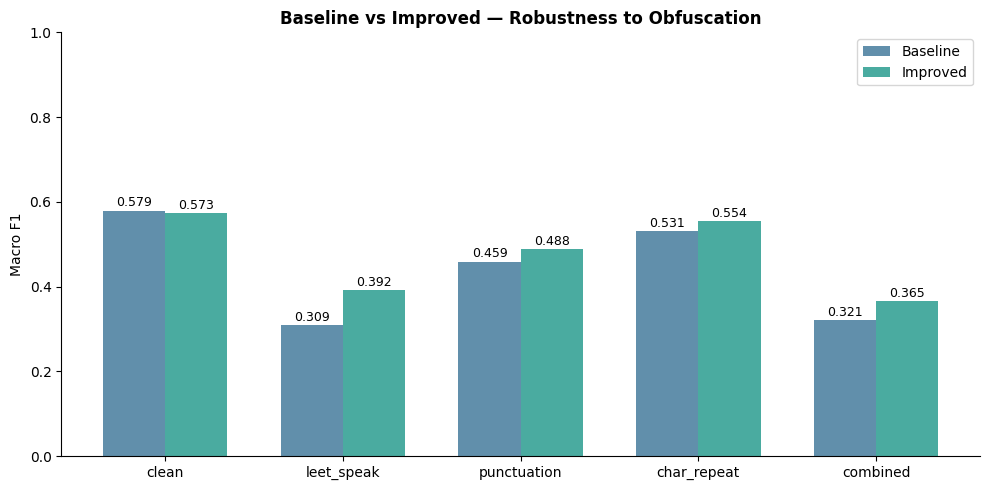

In [28]:
# ── Side-by-side comparison chart ────────────────────────
keys  = list(results_4a.keys())
x     = np.arange(len(keys))
width = 0.35
fig, ax = plt.subplots(figsize=(10,5))
b1 = ax.bar(x-width/2, [results_4a[k] for k in keys], width,
            label="Baseline", color="#457b9d", alpha=0.85)
b2 = ax.bar(x+width/2, [results_4b[k] for k in keys], width,
            label="Improved", color="#2a9d8f", alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(keys)
ax.set_ylabel("Macro F1"); ax.set_ylim(0, 1.0)
ax.set_title("Baseline vs Improved — Robustness to Obfuscation", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("robustness_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

In [30]:
# ── Δ Summary ────────────────────────────────────────────
print("── Δ Summary ──")
header = f"{'Condition':<20} {'Baseline':>10} {'Improved':>10} {'Δ':>10}"
print(header); print("─"*len(header))
for name in results_4a:
    b = results_4a[name]
    imp = results_4b[name]
    print(f"  {name:<18} {b:10.4f} {imp:10.4f} {imp-b:+10.4f}")

── Δ Summary ──
Condition              Baseline   Improved          Δ
─────────────────────────────────────────────────────
  clean                  0.5790     0.5735    -0.0056
  leet_speak             0.3088     0.3916    +0.0827
  punctuation            0.4590     0.4879    +0.0290
  char_repeat            0.5309     0.5539    +0.0230
  combined               0.3214     0.3651    +0.0436


### 5c — Qualitative failure analysis

In [32]:
# Find posts correct on clean but wrong after combined obfuscation
random.seed(RANDOM_SEED)
combined_texts = obf_cache["combined"]
preds_combined, _ = get_predictions(model_4a, combined_texts, test_labels, word2idx)

failures = []
for i, (cp, op, tl) in enumerate(zip(preds_clean_4a, preds_combined, test_labels)):
    if cp == tl and op != tl:
        failures.append({
            "idx": i,
            "text": test_texts[i][:80],
            "obfuscated": combined_texts[i][:80],
            "true": LABEL_NAMES[tl],
            "clean_pred": LABEL_NAMES[cp],
            "obf_pred": LABEL_NAMES[op]
        })

print(f"Posts flipped by combined obfuscation: {len(failures)} / {len(test_labels)} "
      f"({100*len(failures)/len(test_labels):.1f}%)\n")
for ex in random.sample(failures, min(8, len(failures))):
    print(f"  True: {ex['true']:<12} Clean→{ex['clean_pred']:<10} Obf→{ex['obf_pred']}")
    print(f"    {ex['text']}")
    print(f"    → {ex['obfuscated']}\n")

Posts flipped by combined obfuscation: 544 / 1924 (28.3%)

  True: hate         Clean→hate       Obf→normal
    note no nigger was harmed during the making of this film
    → n0te no nig9er w45 h4rmed d.u.r.1.n.9 7he m*4*k*i*n*g of 7his f1lm

  True: offensive    Clean→offensive  Obf→normal
    come on please you forgot you are from europe you think north africa is black yo
    → comm3 on pl3a5e you f*0*r*9*o*t you are from europe y0u thhink nor7h africa is b

  True: hate         Clean→hate       Obf→normal
    amy loves to guzzle down nigger cum
    → amy loves 7o guzzle d-o-w-n nigger cum

  True: hate         Clean→hate       Obf→normal
    o pleez god hates queers both 0 bamas are male both have a penis the mooch is a 
    → o pleez g0d hates que3rs b0000th 0 baaaamas are m4lll3 8oth hav3 a p-e-n-i-s th3

  True: offensive    Clean→offensive  Obf→normal
    niggas really be tryna keep yu around just to be on some bullshit raggedy bitche
    → n-i-9-g-a-s really 8e tryna ke3p yu 4r

---
## Threshold Tuning — Hate Class Recall Analysis

The baseline model uses argmax (highest probability wins). By lowering the decision threshold for the `hate` class, we can increase recall at the cost of precision. This is desirable in content moderation, where missing a hateful post (false negative) is worse than flagging a normal one (false positive).

In [33]:
# ── Threshold sweep on test set (baseline model) ─────────
_, all_probs = get_predictions(model_4a, test_texts, test_labels, word2idx)

thresholds = np.arange(0.15, 0.55, 0.025)
results_th = []

for th in thresholds:
    preds_th = []
    for prob in all_probs:
        if prob[0] >= th:
            preds_th.append(0)
        else:
            preds_th.append(prob.argmax())

    prec = precision_score(test_labels, preds_th, labels=[0], average=None)[0]
    rec  = recall_score(test_labels, preds_th, labels=[0], average=None)[0]
    f1_h = f1_score(test_labels, preds_th, labels=[0], average=None)[0]
    f1_m = f1_score(test_labels, preds_th, average="macro")
    results_th.append({"threshold": th, "hate_precision": prec,
                        "hate_recall": rec, "hate_f1": f1_h, "macro_f1": f1_m})

df_th = pd.DataFrame(results_th)
print(df_th.to_string(index=False, float_format="%.3f"))

 threshold  hate_precision  hate_recall  hate_f1  macro_f1
     0.150           0.588        0.790    0.674     0.567
     0.175           0.596        0.778    0.675     0.568
     0.200           0.603        0.774    0.678     0.570
     0.225           0.607        0.768    0.678     0.571
     0.250           0.615        0.761    0.680     0.573
     0.275           0.620        0.751    0.679     0.575
     0.300           0.622        0.742    0.677     0.575
     0.325           0.627        0.739    0.679     0.577
     0.350           0.629        0.727    0.674     0.576
     0.375           0.630        0.721    0.672     0.576
     0.400           0.634        0.714    0.671     0.576
     0.425           0.637        0.712    0.672     0.578
     0.450           0.637        0.707    0.670     0.577
     0.475           0.640        0.704    0.670     0.578
     0.500           0.641        0.704    0.671     0.579
     0.525           0.641        0.704    0.671     0.5

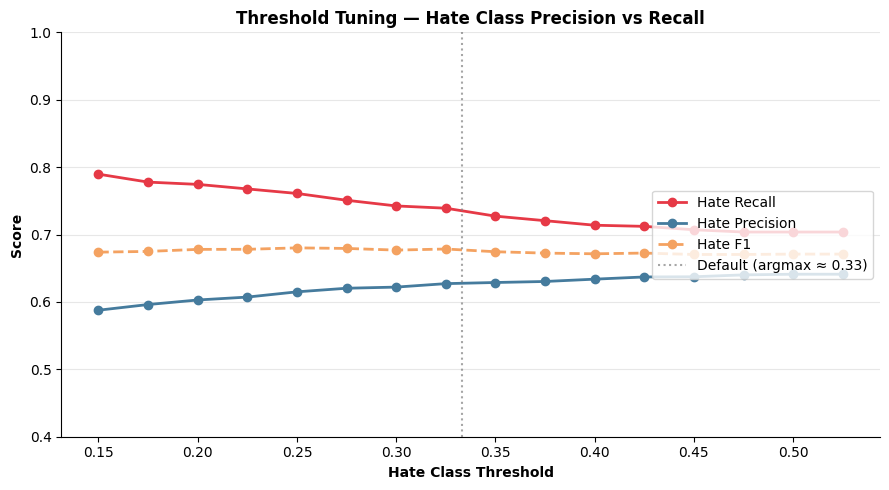

✓ Saved threshold_tuning.png


In [34]:
# ── Precision-Recall tradeoff plot ────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(df_th["threshold"], df_th["hate_recall"], "o-", color="#e63946",
         linewidth=2, label="Hate Recall")
ax1.plot(df_th["threshold"], df_th["hate_precision"], "o-", color="#457b9d",
         linewidth=2, label="Hate Precision")
ax1.plot(df_th["threshold"], df_th["hate_f1"], "o--", color="#f4a261",
         linewidth=2, label="Hate F1")

ax1.axvline(1/3, color="gray", linestyle=":", alpha=0.7, label="Default (argmax ≈ 0.33)")

ax1.set_xlabel("Hate Class Threshold", fontweight="bold")
ax1.set_ylabel("Score", fontweight="bold")
ax1.set_title("Threshold Tuning — Hate Class Precision vs Recall", fontweight="bold")
ax1.legend(loc="center right")
ax1.set_ylim(0.4, 1.0)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved threshold_tuning.png")

In [35]:
# ── Compare default vs tuned threshold ────────────────────
default_row = df_th.iloc[(df_th["threshold"] - 1/3).abs().argsort().iloc[0]]
best_recall_row = df_th[df_th["hate_recall"] >= 0.90].iloc[-1] if (df_th["hate_recall"] >= 0.90).any() else df_th.iloc[df_th["hate_recall"].argmax()]

print("── Default (argmax) ──")
print(f"   Threshold     : {default_row['threshold']:.3f}")
print(f"   Hate Precision: {default_row['hate_precision']:.3f}")
print(f"   Hate Recall   : {default_row['hate_recall']:.3f}")
print(f"   Hate F1       : {default_row['hate_f1']:.3f}")
print(f"   Macro F1      : {default_row['macro_f1']:.3f}")

print(f"\n── Tuned (recall ≥ 0.90) ──")
print(f"   Threshold     : {best_recall_row['threshold']:.3f}")
print(f"   Hate Precision: {best_recall_row['hate_precision']:.3f}")
print(f"   Hate Recall   : {best_recall_row['hate_recall']:.3f}")
print(f"   Hate F1       : {best_recall_row['hate_f1']:.3f}")
print(f"   Macro F1      : {best_recall_row['macro_f1']:.3f}")

delta_rec  = best_recall_row['hate_recall'] - default_row['hate_recall']
delta_prec = best_recall_row['hate_precision'] - default_row['hate_precision']
print(f"\n── Tradeoff ──")
print(f"   Recall gain   : +{delta_rec:.3f}")
print(f"   Precision cost: {delta_prec:.3f}")

── Default (argmax) ──
   Threshold     : 0.325
   Hate Precision: 0.627
   Hate Recall   : 0.739
   Hate F1       : 0.679
   Macro F1      : 0.577

── Tuned (recall ≥ 0.90) ──
   Threshold     : 0.150
   Hate Precision: 0.588
   Hate Recall   : 0.790
   Hate F1       : 0.674
   Macro F1      : 0.567

── Tradeoff ──
   Recall gain   : +0.051
   Precision cost: -0.039


---
## Save to Google Drive

In [36]:
from google.colab import drive
drive.mount("/content/drive")
import os

os.makedirs(DRIVE_DIR, exist_ok=True)

torch.save(model_4a.state_dict(), os.path.join(DRIVE_DIR, "bilstm_baseline.pt"))
torch.save(model_4b.state_dict(), os.path.join(DRIVE_DIR, "bilstm_improved.pt"))
print("✓ Models saved to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Models and tokenizer saved to Drive
